# 01 — EDA

One map of the whole dataset, then the findings read off it.
Source: `pe.v_leads_curated` — the same view the pipeline and the dashboard read.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, ".")
from pe_style import *

df = leads_db()
Y = "completed_purchase"
BASE = df[Y].mean()

raw_rows = int(sql("SELECT count(*) AS n FROM pe.leads").iloc[0, 0])
dupes = int(sql("SELECT count(*) - count(DISTINCT lead_id) AS n FROM pe.leads").iloc[0, 0])

print(f"pe.leads            {raw_rows:,} rows, {dupes} duplicate lead_ids")
print(f"v_leads_curated     {len(df):,} leads")
print(f"period              {df['created_at'].min():%Y-%m-%d} → {df['created_at'].max():%Y-%m-%d}")
print(f"base rate           {BASE:.2%}")

pe.leads            50,180 rows, 180 duplicate lead_ids
v_leads_curated     50,000 leads
period              2026-04-01 → 2026-08-28
base rate           9.17%


## 1. The columns, by family

The grouping used in every chart from here on.

**context** known on arrival · **offer** what we put on the table · **clock** three time
columns in three units · **behaviour** what the user did · **outcome** what we predict

In [2]:
fam = pd.DataFrame(PROFILE, columns=["column", "family", "kind"])
for f in FAMILIES:
    block = fam[fam["family"] == f]
    print(f"{f:<10} ({len(block)})  " + ", ".join(
        f"{r.column}" for r in block.itertuples()))
print()
print(pd.crosstab(fam["family"], fam["kind"]).to_string())

context    (7)  product_type, channel, device, payment_type, insurance_company, partner, city
offer      (3)  price, discount_percent, expected_margin
clock      (3)  days_to_policy_expiry, minutes_since_abandonment, days_since_last_visit
behaviour  (6)  sessions_last_7d, offer_views_last_7d, price_comparisons_last_7d, visited_offer_page, has_previous_purchase, incoming_call_last_24h
outcome    (1)  completed_purchase

kind       categorical  discrete  flag  numeric
family                                         
behaviour            0         3     3        0
clock                0         0     0        3
context              7         0     0        0
offer                0         0     0        3
outcome              0         0     1        0


### Every column at a glance

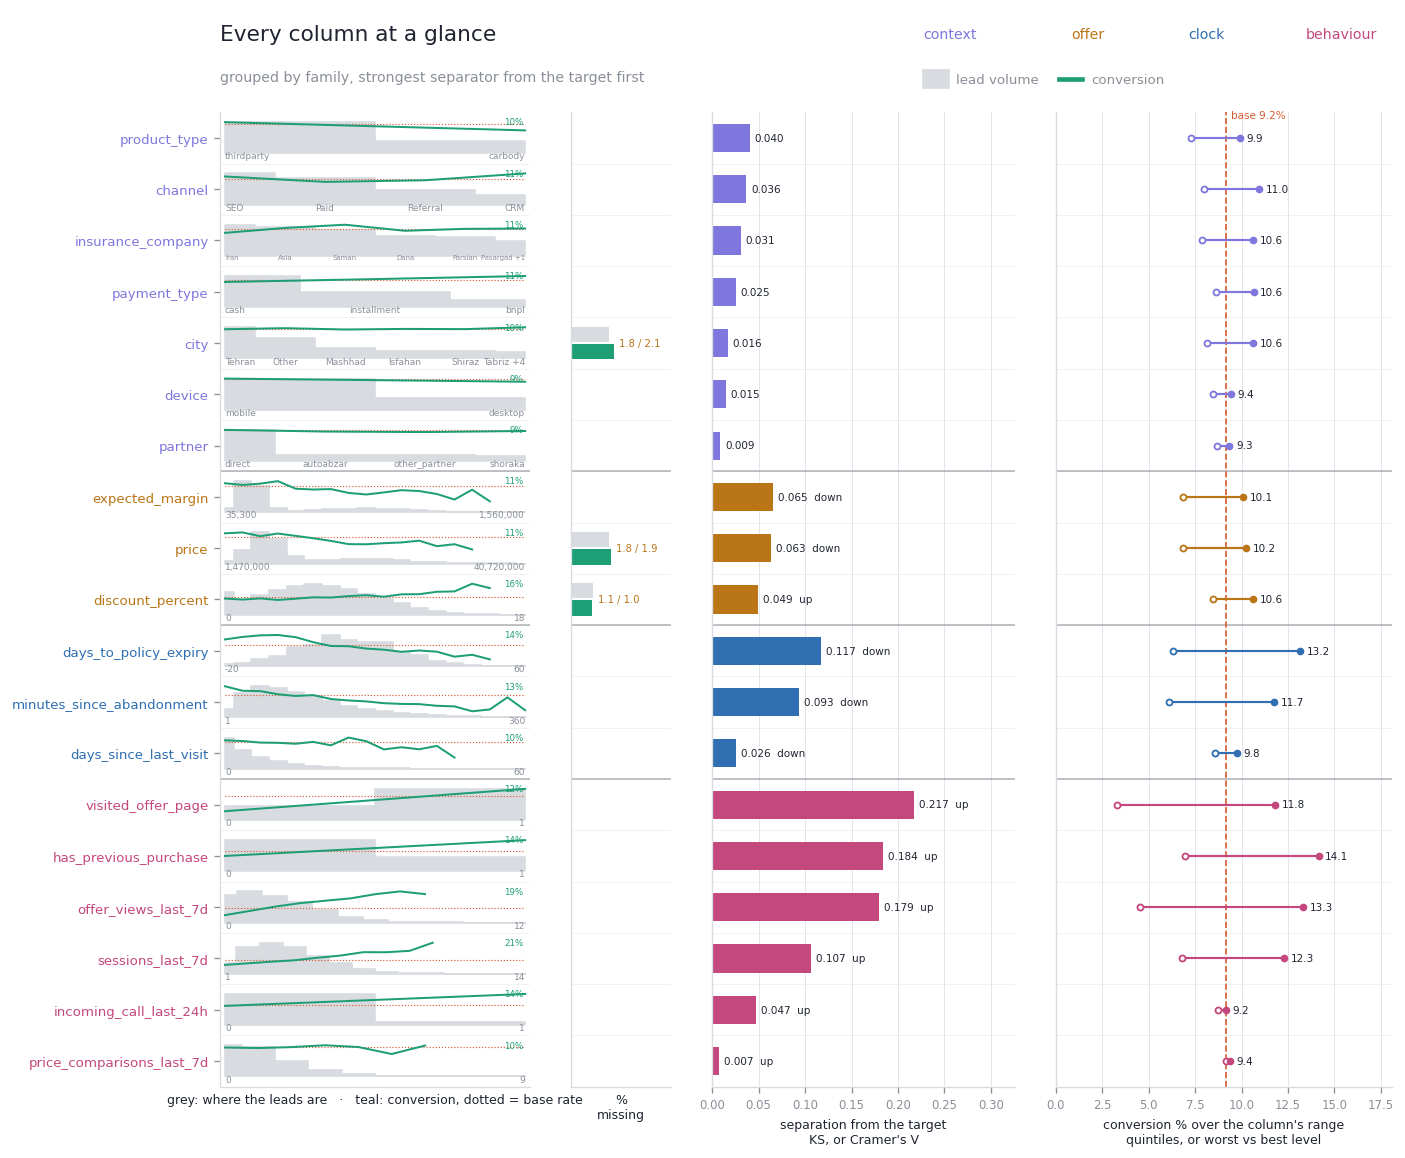

In [3]:
save(column_sheet(df), "01_columns");

One row per column: where the leads are (grey) with conversion drawn through them (teal),
then missingness, separation from the target, and that separation in conversion points.
Each row is scaled to its own top rate — slopes compare, heights do not.

Two densities would sit on top of each other at a 9% base rate, and a correlation
coefficient would ask whether a column moves *linearly* with a 0/1 outcome. Hence
conversion drawn directly, and KS / Cramér's V as the measure.

## 2. How the columns relate to each other

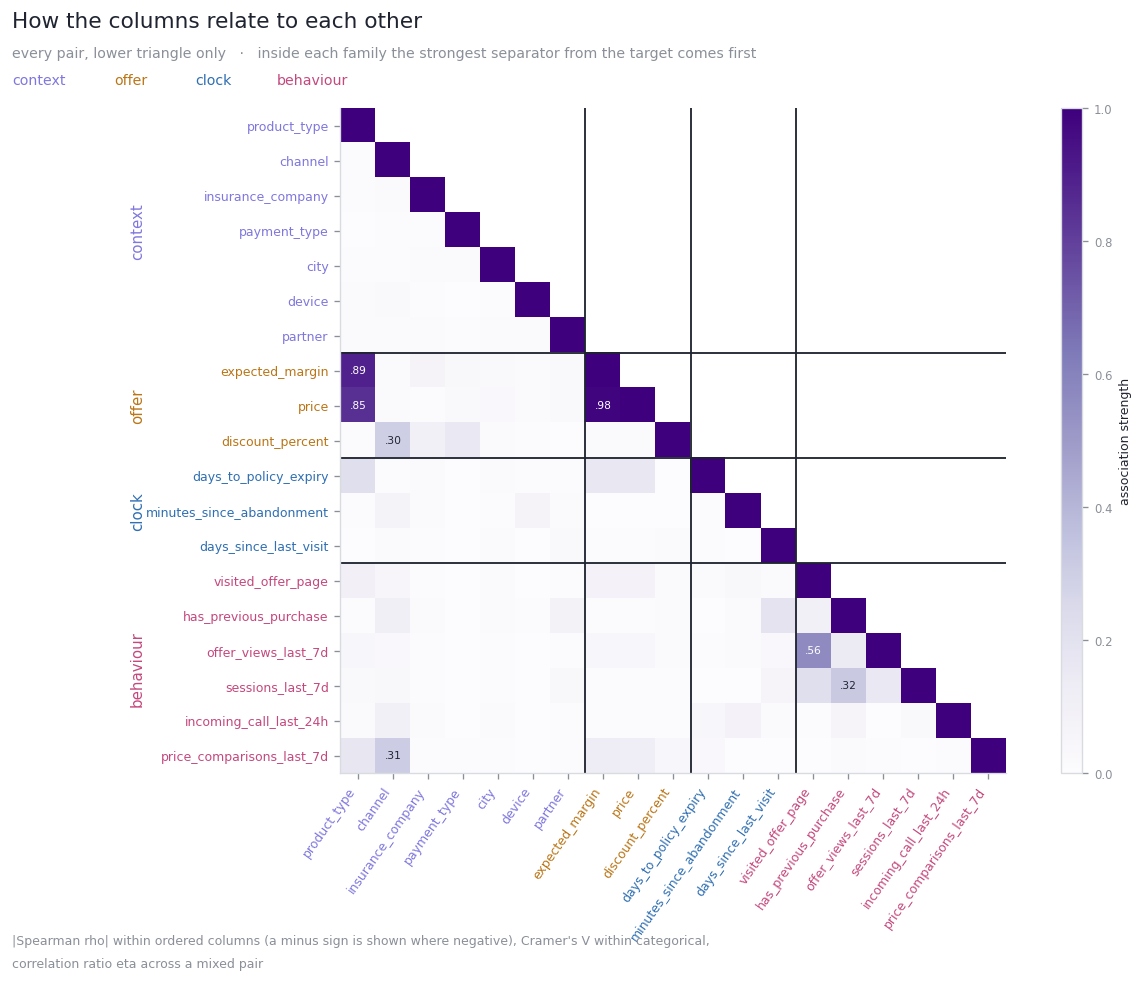

In [4]:
fig, info = dataset_map(df)
save(fig, "01_matrix");

Same row order, lower triangle only. Spearman rho for ordered × ordered, Cramér's V for
categorical × categorical, η for mixed.

## 3. Findings

### The matrix is almost empty, and that is the headline

In [5]:
A = info["assoc"].abs()
off = A.where(np.triu(np.ones(A.shape, dtype=bool), k=1)).stack()
print(f"pairs plotted                 {len(off)}")
print(f"above 0.25                    {(off >= 0.25).sum()}")
print(f"above 0.50                    {(off >= 0.50).sum()}")
print(f"median pairwise association   {off.median():.3f}")
print(f"max separation from target    {info['separation'].max():.3f}")

pairs plotted                 171
above 0.25                    7
above 0.50                    4
median pairwise association   0.013
max separation from target    0.217


171 pairs, median 0.03. No column separates the outcome by more than 0.22.

**So:** the model has to accumulate weak signals, not exploit a strong one — and nothing
looks implausible, which is where leakage would have shown first.

**But part of the emptiness is the generator, not the domain.** Columns that describe the
same behaviour — sessions, offer views, price comparisons, days since last visit — barely
associate with each other, where real traffic would have them moving together. Treat the
"no interactions to find" result as a fact about *this file*, and re-test it on production
data before concluding the same about the business.

### Three pairs are duplicates, not correlations

In [6]:
print(pairs_above(info, 0.5).round(3).to_string())
print()
ratio = (df["expected_margin"] / df["price"] * 100)
print("expected_margin as % of price, by product:")
print(ratio.groupby(df["product_type"]).agg(["mean", "std"]).round(3).to_string())
print("\nprice median by product:")
print(df.groupby("product_type")["price"].median().round(0).to_string())

expected_margin     price                  0.984
product_type        expected_margin        0.894
                    price                  0.845
visited_offer_page  offer_views_last_7d    0.561

expected_margin as % of price, by product:
               mean    std
product_type              
carbody       3.869  0.177
thirdparty    2.669  0.177

price median by product:
product_type
carbody       19560000.0
thirdparty     7490000.0


`expected_margin` ≈ `price` × a per-product constant (0.98), and `product_type` explains
both at η ≈ 0.85 — one column written three ways.

**So:** margin becomes the ranking weight, not an input. And raw `price` is dropped for a
second reason beyond redundancy: because `product_type` sets its scale, a model given raw
price largely learns *which product this is* and carries that bias into every comparison
between a carbody lead and a thirdparty one. The within-product percentile is the same
information with the product effect divided out.

**That percentile is itself a judgement call.** It says "expensive for its product", so a
lead from a genuinely premium insurer looks the same as an overpriced cheap one. Dropping
it entirely would remove one more path for price to bias the queue; the cost is that we
would stop distinguishing a costly-but-converting insurer from the rest, which is real
support to lose. It is kept, and it is the first feature to re-test if the queue ever
looks skewed by product or company.

### A lead can buy without ever reaching the offer page

In [7]:
v, o = "visited_offer_page", "offer_views_last_7d"

nv = df[df[v] == 0]
print(f"never reached the page:  {len(nv):,} leads, {int(nv[Y].sum())} of them bought")
print(f"conversion, reached     {df[df[v] == 1][Y].mean():.2%}")
print(f"conversion, never       {nv[Y].mean():.2%}\n")
for (a, b), name in [((0, 0), "neither"), ((1, 0), "renewal"),
                     ((0, 1), "inbound call"), ((1, 1), "renewal + call")]:
    s = nv[(nv["has_previous_purchase"] == a) & (nv["incoming_call_last_24h"] == b)]
    print(f"  {name:<16} n={len(s):>6,}   {s[Y].mean():.2%}")
print(f"\nprice present regardless of the visit: "
      f"{df.groupby(v)['price'].apply(lambda s: 1 - s.isna().mean()).round(4).to_dict()}")

never reached the page:  15,475 leads, 514 of them bought
conversion, reached     11.79%
conversion, never       3.32%

  neither          n=10,894   2.59%
  renewal          n= 3,417   4.86%
  inbound call     n=   782   4.22%
  renewal + call   n=   382   8.64%

price present regardless of the visit: {0: 0.9811, 1: 0.9816}


Among leads that never reached the page, a prior purchase or an inbound call each roughly
doubles conversion and together nearly triple it — 8.6% against 11.8% for the self-serve
path. `price` is present either way, so the quote exists server-side.

**So:** there is a second route to buying (renewal link, agent on the phone), and
`visited_offer_page` is funnel depth rather than a precondition.

**And it settles what the label means.** These leads bought *without* the session the row
describes. The dataset deliberately contains people who did not buy in this session and
bought later — `completed_purchase` is a purchase at some point after the snapshot, not a
completion of the abandoned checkout. Everything downstream reads that way: the queue
ranks who will buy next, not who was about to click.

### The clock columns contradict their own names

In [8]:
for c in cols_of(family="clock"):
    v_ = pd.to_numeric(df[c], errors="coerce")
    print(f"{c:<28} min {v_.min():>7.1f}   max {v_.max():>7.1f}   "
          f"nulls {v_.isna().sum():>3}   at max {int((v_ == v_.max()).sum()):>5,}")

m = "minutes_since_abandonment"
local = df[m].between(330, 359).sum() / 30
print(f"\n{m}: 330–359 holds {df[m].between(330, 359).sum()} leads (≈{local:.1f}/min), "
      f"exactly 360 holds {int((df[m] == 360).sum())} — {(df[m] == 360).sum() / local:.0f}× the local rate")

e = "days_to_policy_expiry"
print(f"\n{e} < 0: {(df[e] < 0).mean():.1%} of leads, converting at "
      f"{df[df[e] < 0][Y].mean():.2%} against {df[df[e] >= 0][Y].mean():.2%}")

days_to_policy_expiry        min   -20.0   max    60.0   nulls   0   at max     3
minutes_since_abandonment    min     1.0   max   360.0   nulls   0   at max   146
days_since_last_visit        min     0.0   max    60.0   nulls   0   at max    26

minutes_since_abandonment: 330–359 holds 141 leads (≈4.7/min), exactly 360 holds 146 — 31× the local rate

days_to_policy_expiry < 0: 14.3% of leads, converting at 13.10% against 8.51%


- `minutes_since_abandonment` — never 0, and 360 holds ~31× the local density. **A clip:**
  right-censored at six hours, no evidence past it.
- `days_to_policy_expiry` — goes **negative**, and a lapsed policy converts best of all.
  Keep the sign.
- `days_since_last_visit` — stops dead at 60 with no nulls, so "never visited" is encoded
  nowhere.

**Two of those three contradict their own names, which is a property of synthetic data,
not of the business.** A real warehouse would not encode "never visited" nowhere, and a
real clock would not stop dead at 60. They are taken at face value and handled explicitly
rather than being explained away.

### `days_since_last_visit` associates with nothing — including what it must

In [9]:
s_, d_ = "sessions_last_7d", "days_since_last_visit"
print(info["assoc"][d_].drop(d_).abs().sort_values(ascending=False).head(5).round(3).to_string())
print(f"\nmin(sessions_last_7d)               {int(df[s_].min())}")
print(f"leads with dslv > 7                 {(df[d_] > 7).mean():.1%}")
print(f"same, among offer_views_last_7d ≥ 1 {(df[df[o] >= 1][d_] > 7).mean():.1%}")
t = (df.groupby(s_).apply(lambda g: pd.Series({"leads": len(g), "dslv>7": (g[d_] > 7).mean()}),
                          include_groups=False).query("leads >= 300"))
print(); print(t.round(3).to_string())

has_previous_purchase    0.190
sessions_last_7d         0.058
offer_views_last_7d      0.030
partner                  0.024
channel                  0.019

min(sessions_last_7d)               1
leads with dslv > 7                 36.4%
same, among offer_views_last_7d ≥ 1 36.0%

                    leads  dslv>7
sessions_last_7d                 
1                  4222.0   0.393
2                  9934.0   0.388
3                 11664.0   0.378
4                 10048.0   0.361
5                  6810.0   0.346
6                  3981.0   0.326
7                  1955.0   0.307
8                   846.0   0.298
9                   366.0   0.301


Every lead has `sessions_last_7d ≥ 1`, yet 36% report a last visit older than 7 days —
and that barely moves (39% → 30%) as sessions rise, where one shared clock would force it
to zero.

**This pair cannot both be true, so the columns were drawn independently** — the same
synthetic-data signature as the flat timestamps in notebook 02. Read it as profile
staleness, and never combine it arithmetically with the session counters.

### Missing values are few, but not random

In [10]:
print(info["missing"].round(3).to_string())
print()
print((df.assign(m=df["price"].isna()).groupby("channel")["m"].mean() * 100)
      .round(2).sort_values(ascending=False).to_string())

city                1.864
price               1.856
discount_percent    1.082

channel
Referral    3.52
CRM         1.73
SEO         1.47
Paid        1.46


`price` is missing ~3.5% on one channel against ~1.5% elsewhere — not MCAR.

**So:** flag it (`price_missing`, `discount_missing`), then impute **inside**
`product_type` — a global median lands between two populations that share no price range.

### Two columns carry nothing

In [11]:
print(info["separation"].tail(5).round(4).to_string())
print()
print(rate_table(df, "price_comparisons_last_7d", min_n=200)[["n", "rate"]].round(4).to_string())
print()
print(df.groupby("city")[Y].agg(n="count", rate="mean").query("n >= 200")
        .sort_values("rate").round(4).to_string())

payment_type                 0.0254
city                         0.0165
device                       0.0146
partner                      0.0088
price_comparisons_last_7d    0.0073

                               n    rate
price_comparisons_last_7d               
0                          18217  0.0917
1                          17322  0.0899
2                           9277  0.0929
3                           3515  0.0987
4                           1213  0.0932
5                            338  0.0710

             n    rate
city                  
Qom       1966  0.0814
Mashhad   4834  0.0887
Tehran   15140  0.0896
Shiraz    3537  0.0899
Isfahan   3855  0.0905
Rasht     2052  0.0916
Ahvaz     2024  0.0924
Other     9749  0.0928
Tabriz    2963  0.0955
Karaj     2948  0.1062


`price_comparisons_last_7d` moves conversion 9.1% → 9.6% across its whole range; `city`
has 11 scattered levels. Both measured, then **excluded** — worth re-testing as data
grows, since "no signal at 50k rows" is a measurement, not a law.

### And the map hides one thing: this is not one population

                n  rate
created_at             
2026-04     10081  9.76
2026-05     10245  9.72
2026-06      9840  9.49
2026-07     10454  9.36
2026-08      9380  7.38


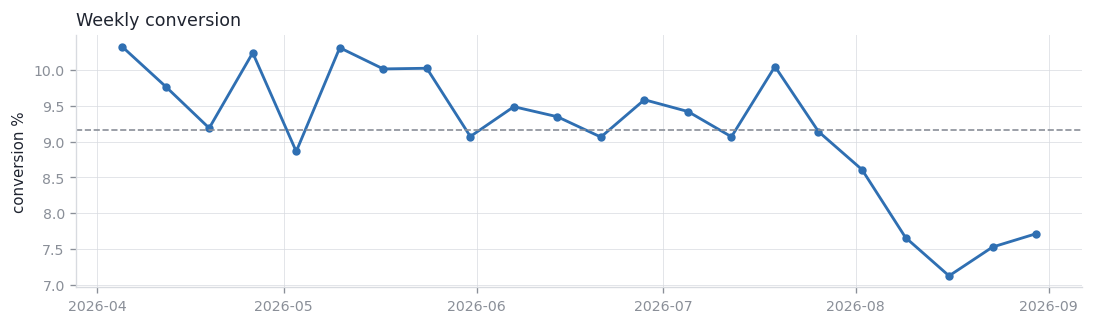

In [12]:
monthly = (df.groupby(df["created_at"].dt.strftime("%Y-%m"))[Y]
             .agg(n="count", rate="mean"))
print(monthly.assign(rate=lambda d: (d["rate"] * 100).round(2)).to_string())

fig, ax = plt.subplots(figsize=(9.2, 2.8))
wk = (df.set_index("created_at").resample("W")[Y].agg(n="count", rate="mean")
        .query("n >= 300"))
ax.plot(wk.index, wk["rate"] * 100, "o-", color=BLUE, lw=1.7, ms=4)
ax.axhline(BASE * 100, ls="--", lw=1, color=MUTED)
ax.set_title("Weekly conversion"); ax.set_ylabel("conversion %")
save(fig, "01_weekly_trend");

Five months averaged into one picture. Split by time: ~9.5% April–July, **7.4% in
August**, and it does not recover. That is the whole reason the split is temporal —
section 4 measures what moved.

## 4. Do the arriving leads change, or only the outcome?

August moved the *outcome*. Whether the *inputs* moved with it decides the response:
inputs moved → retrain on recent data; inputs flat → retraining cannot restore the level,
so watch calibration instead.

**The test:** April is the reference, every later month is compared back to it column by
column, and the answer is in leads — the share of that month's leads that would have to
change bin to look like April. Each cell carries its own noise floor, and colour is the
value over that floor, so only a real move takes colour.

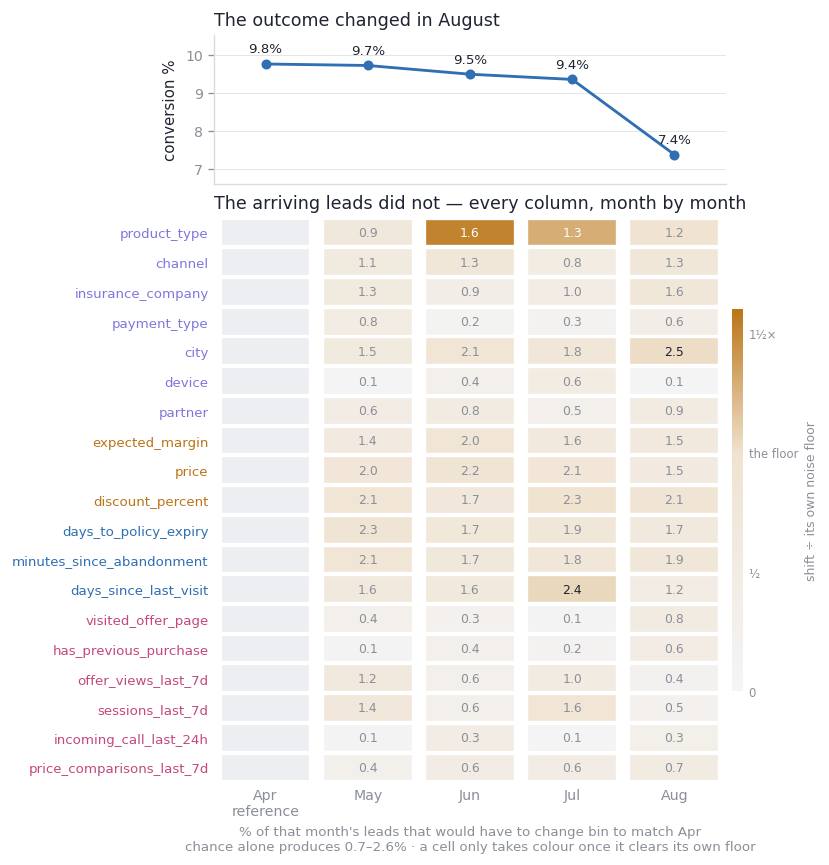

In [13]:
fig, shift = shift_over_time(df)
save(fig, "01_shift_over_time");

Conversion falls off a cliff in August. The grid underneath stays flat.

### Four cells of 76 clear their floor — which is what chance gives

In [14]:
moved, floor = shift["moved_pct"], shift["noise_floor"]
over = moved > floor
print(f"cells above their own floor   {int(over.to_numpy().sum())} of {moved.size}"
      f"   (a 95th-percentile floor gives {0.05 * moved.size:.0f} by construction)")
print(f"worst cell anywhere           {(moved / floor).to_numpy().max():.2f}\u00d7 its floor")
print(f"largest move in August        {moved.iloc[:, -1].max():.1f}% of leads "
      f"({moved.iloc[:, -1].idxmax()})\n")
print((pd.crosstab(df["created_at"].dt.strftime("%b"), df["product_type"],
                   normalize="index") * 100).round(1).to_string())

cells above their own floor   4 of 76   (a 95th-percentile floor gives 4 by construction)
worst cell anywhere           1.52× its floor
largest move in August        2.5% of leads (city)

product_type  carbody  thirdparty
created_at                       
Apr              28.7        71.3
Aug              27.5        72.5
Jul              27.3        72.7
Jun              27.1        72.9
May              27.8        72.2


- A 95th-percentile floor is crossed by ~4 cells of 76 when nothing has moved. The grid
  shows 4, none by more than half, and no column twice in a row.
- The one warm cell (`product_type`) moves 1.5 points in May and back. August is its
  calmest month.

**Across five months, the arriving leads are the same leads.**

### The rates fell by one factor, and the ranking survived

largest mix effect   visited_offer_page  -0.073pp of the -2.20pp total
lift correlation     0.834 across 113 bins

               column  lift_ref  lift_cur     z      n
      expected_margin      0.94      1.23  2.17  922.0
                price      1.08      0.83 -2.14  900.0
     discount_percent      0.93      0.70 -2.11  944.0
days_to_policy_expiry      1.00      0.79 -2.10 1173.0


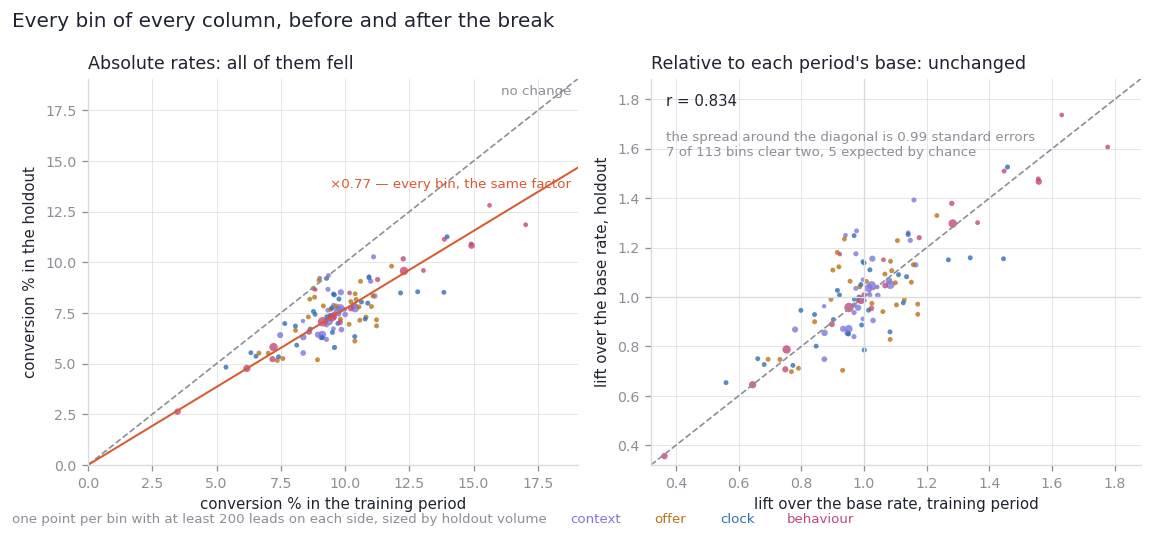

In [15]:
holdout = shift_table(df)
fig, bins = lift_stability(df, table=holdout)
save(fig, "01_shift_lift")

worst = holdout["mix_pp"].abs().idxmax()
print(f"largest mix effect   {worst}  {holdout.loc[worst, 'mix_pp']:+.3f}pp "
      f"of the {(holdout.attrs['base_cur'] - holdout.attrs['base_ref']) * 100:+.2f}pp total")
print(f"lift correlation     {np.corrcoef(bins['lift_ref'], bins['lift_cur'])[0, 1]:.3f} "
      f"across {len(bins)} bins\n")
print(bins.reindex(bins["z"].abs().sort_values(ascending=False).index).head(4)
        [["column", "lift_ref", "lift_cur", "z", "n"]].round(2).to_string(index=False))

- Every bin of every column converts worse by **the same factor** — the left panel sits
  on a ×0.77 line rather than scattering.
- Divided by each period's own base rate, the bins land on the diagonal: order and
  magnitude preserved.
- Remaining spread is 0.99 standard errors — sampling noise.

**The level of every probability is wrong by a common factor; the order is not.**

### What that rules out

No covariate shift, to the limit 50,000 leads can detect. The −2.2pp is **concept
shift** — the same leads converting less — which decides three things:

- **Retraining will not recover the level.** Recalibration, not repair.
- **The ranking is the durable part**, so model choice goes on ranking metrics and
  calibration is re-measured every run.
- **An input-drift alarm would never have fired.** What moves is the outcome, and through
  it the score distribution — which is what `monitoring_snapshots` records.

## 5. What the findings changed

| Finding | Decision |
|---|---|
| 180 duplicate `lead_id`s, identical features | dedupe in `v_leads_curated`, keep the latest |
| association near zero, max target separation 0.22 | accumulate weak signals; no leakage to exploit |
| behaviour columns barely associate with each other | a synthetic-data artefact — re-test on production data |
| `expected_margin` = price × constant (0.98) | ranking weight, not a model input |
| `product_type` explains price (η 0.85) | drop raw `price` — it encodes the product and biases carbody against thirdparty — and use the within-product percentile |
| `visited_offer_page = 0` still buys | funnel depth, not a precondition — and the label is a *later* purchase, not this session's |
| `minutes_since_abandonment` censored at 360 | re-infer inside 360 min, decay beyond |
| negative `days_to_policy_expiry` converts best | keep the sign, add `is_expired` |
| `days_since_last_visit` on its own clock | keep raw, never combine with session counts |
| `price` missing 3.5% on one channel vs 1.5% | flag, then impute inside `product_type` |
| `price_comparisons_last_7d`, `city` flat | excluded |
| conversion 9.5% → 7.4% in August | temporal split, newest 28 days held out |
| no column past its noise floor in any month | no covariate shift |
| mix effect ≤ 0.07pp of the −2.2pp move | concept shift — measured on the outcome |
| lift per bin preserved (r 0.83, spread 0.99 SE) | rank the queue, recalibrate every run |

Two of these are worth revisiting on real data rather than treating as settled: the
within-product price percentile (it can still bias the queue by product or insurer), and
every finding that rests on columns the generator drew independently.